In [1]:
import pandas as pd

In [5]:
df=pd.read_csv('/Users/vishishtareddy/Desktop/ml/data/raw/Sleep_health_and_lifestyle_dataset.csv')

In [8]:
df.shape


(374, 13)

In [9]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [11]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(242)

In [54]:
df = df.drop_duplicates()

In [ ]:

df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [36]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [37]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [12]:
df.drop("Person ID", axis=1, inplace=True)

In [49]:
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)
df.drop("Blood Pressure", axis=1, inplace=True)

KeyError: 'Blood Pressure'

In [24]:
df["BMI Category"].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [25]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

In [27]:
df.groupby("BMI Category")[["Heart Rate", "Systolic", "Diastolic"]].mean()

,Heart Rate,Systolic,Diastolic
BMI Category,,,
Normal,68.976852,123.606481,80.601852
Obese,84.300000,139.200000,90.200000
Overweight,70.945946,135.054054,90.182432


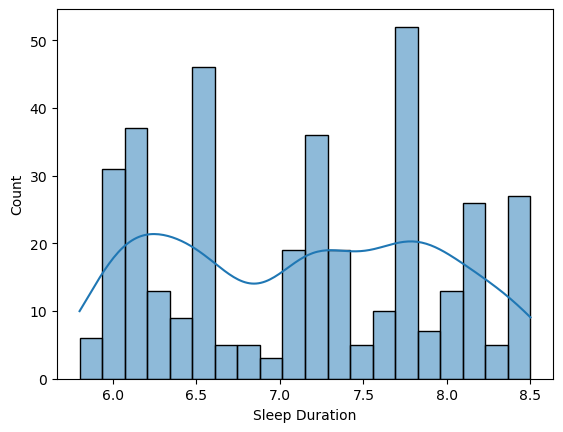

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["Sleep Duration"], bins=20, kde=True)
plt.show()

<Axes: xlabel='Stress Level', ylabel='Count'>

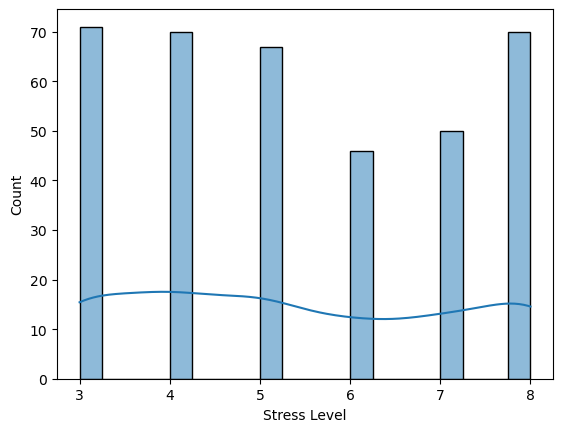

In [19]:
sns.histplot(df["Stress Level"], bins=20, kde=True)

<Axes: xlabel='Physical Activity Level', ylabel='Count'>

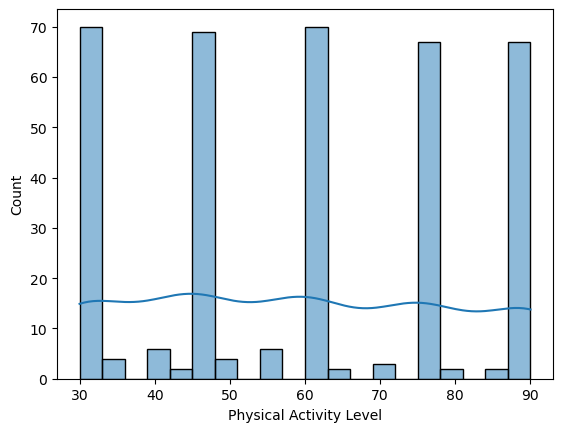

In [20]:
sns.histplot(df["Physical Activity Level"], bins=20, kde=True)

<Axes: xlabel='Daily Steps', ylabel='Count'>

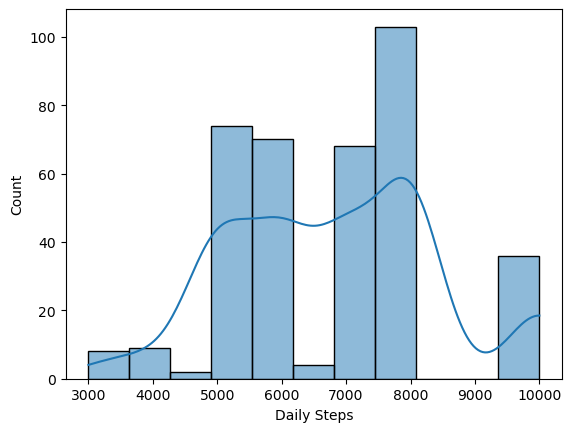

In [21]:
sns.histplot(df["Daily Steps"], kde=True)

<Axes: xlabel='Heart Rate'>

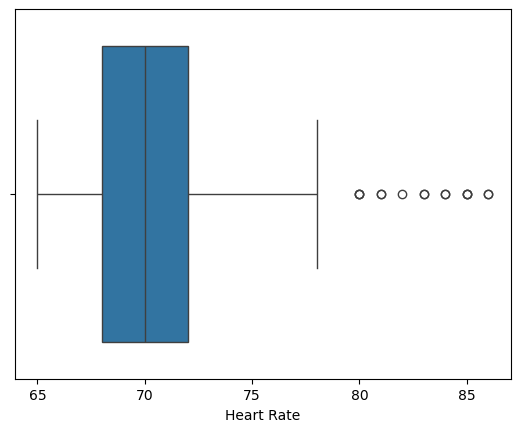

In [22]:
sns.boxplot(x=df["Heart Rate"])

([0, 1, 2],
 [Text(0, 0, 'Overweight'), Text(1, 0, 'Normal'), Text(2, 0, 'Obese')])

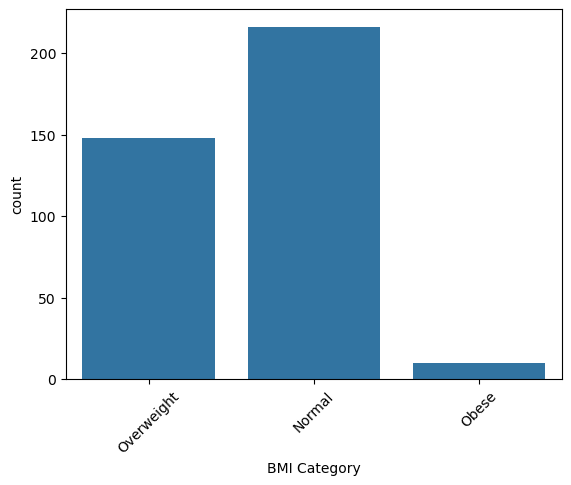

In [26]:
sns.countplot(x="BMI Category", data=df)
plt.xticks(rotation=45)

<Axes: xlabel='Sleep Duration', ylabel='Stress Level'>

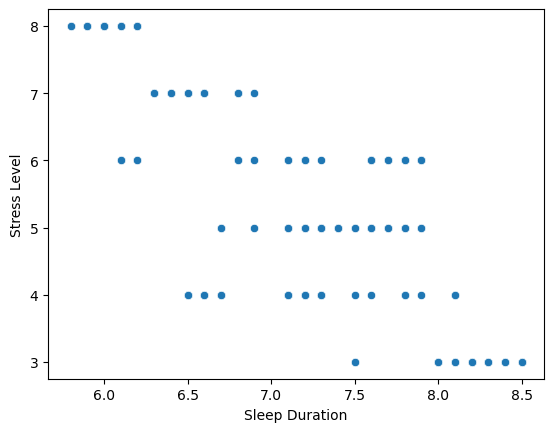

In [28]:
sns.scatterplot(x="Sleep Duration", y="Stress Level", data=df)

In [29]:
df["Sleep Duration"].corr(df["Stress Level"])

np.float64(-0.8110230278940451)

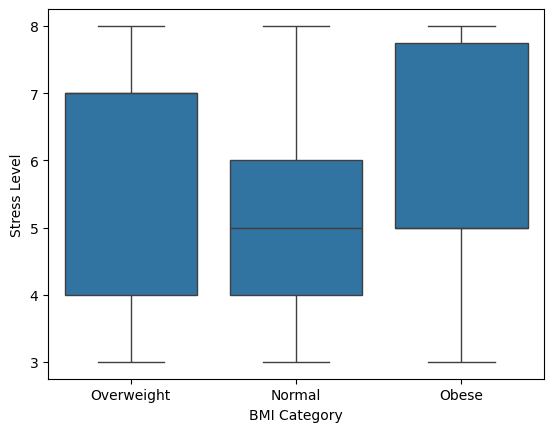

In [30]:
sns.boxplot(x="BMI Category", y="Stress Level", data=df)
plt.show()

<Axes: xlabel='BMI Category', ylabel='Physical Activity Level'>

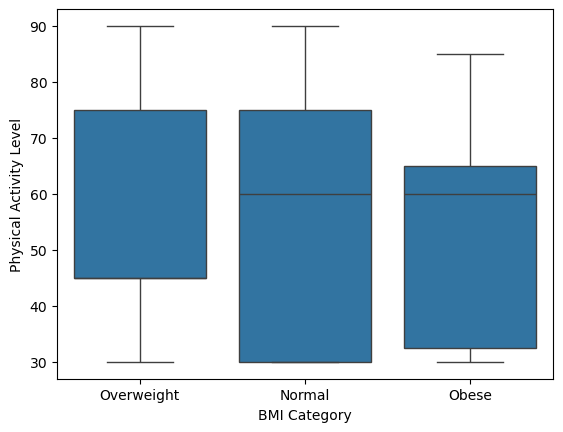

In [31]:
sns.boxplot(x="BMI Category", y="Physical Activity Level", data=df)

<Axes: xlabel='Daily Steps', ylabel='Heart Rate'>

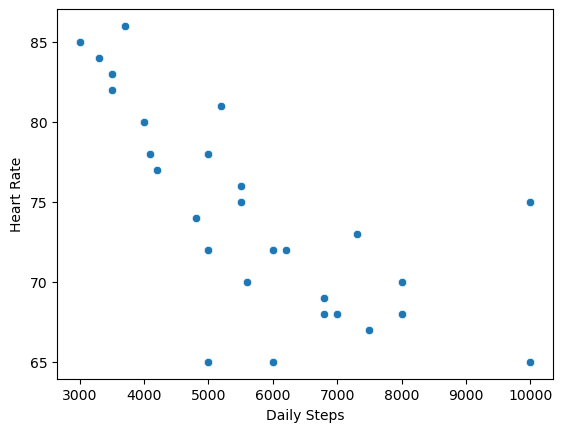

In [32]:
sns.scatterplot(x="Daily Steps", y="Heart Rate", data=df)

<Axes: xlabel='Sleep Disorder', ylabel='Sleep Duration'>

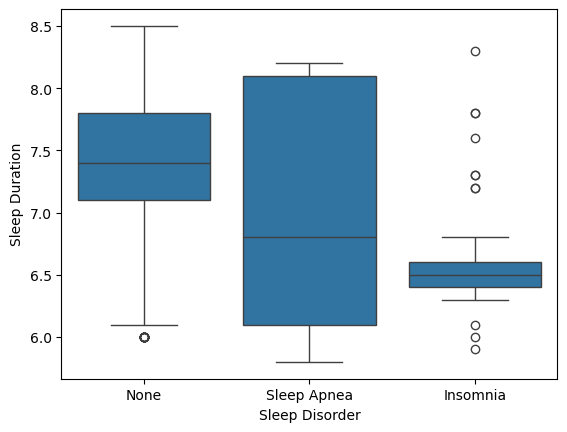

In [38]:
sns.boxplot(x="Sleep Disorder", y="Sleep Duration", data=df)

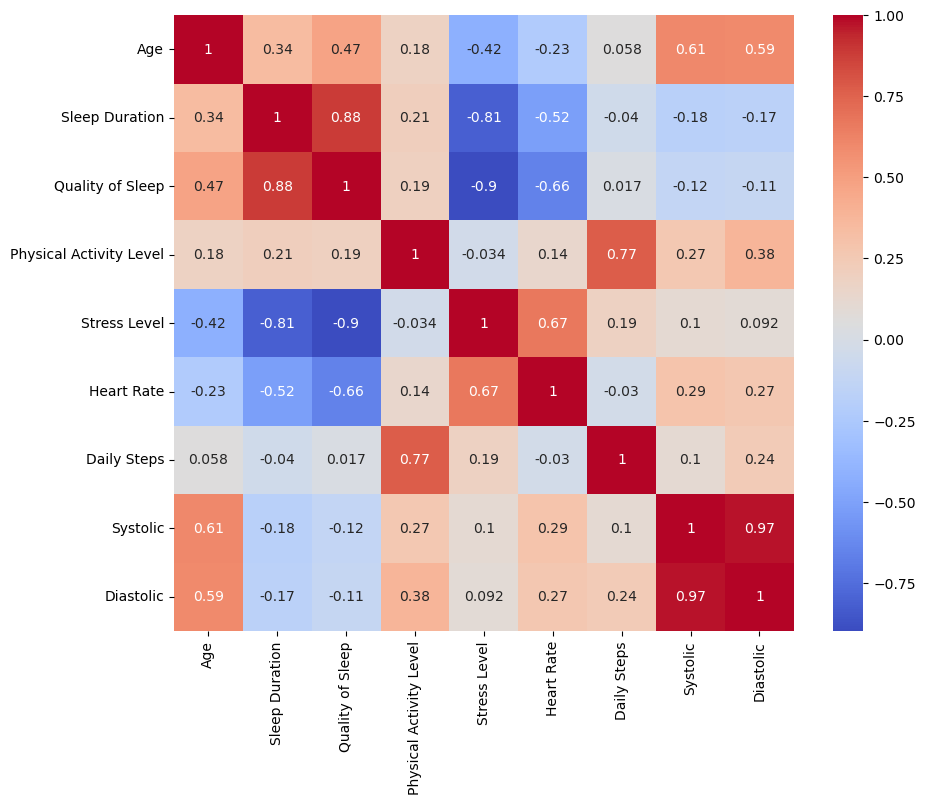

In [45]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [51]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic
0,Male,27,Software Engineer,6.1,42,6,Overweight,77,4200,None,126
1,Male,28,Doctor,6.2,60,8,Normal,75,10000,None,125
2,Male,28,Doctor,6.2,60,8,Normal,75,10000,None,125
3,Male,28,Sales Representative,5.9,30,8,Obese,85,3000,Sleep Apnea,140
4,Male,28,Sales Representative,5.9,30,8,Obese,85,3000,Sleep Apnea,140


In [52]:
df["Activity_Index"] = df["Physical Activity Level"] * df["Daily Steps"]
df.drop(["Physical Activity Level", "Daily Steps"], axis=1, inplace=True)

Dataset contains demographic, lifestyle, physiological, and health outcome features.

No major missing values after cleaning; duplicates removed.

Strong negative correlation between Sleep Duration and Stress Level (~ -0.81).

Very strong negative relationship between Stress and Sleep Quality (~ -0.90).

Sleep-related features form a dominant psychological health block.

Strong positive correlation between Physical Activity and Daily Steps (~ 0.77).

Higher physical activity is associated with lower heart rate.

Age positively correlates with Systolic BP (~ 0.6).

Extremely high correlation between Systolic and Diastolic BP (~ 0.97).

Redundant BP features were combined to reduce multicollinearity.

Obese category shows:

Higher stress levels

Lower sleep duration

Slightly elevated heart rate

Stress appears to be the strongest behavioral predictor of BMI.

Sleep shows moderate negative relationship with BMI.

Activity shows weaker but noticeable influence on BMI.

Sleep Disorder groups are logically consistent:

Insomnia → lower sleep duration

Sleep Apnea → cardiovascular variation

Dataset exhibits clear lifestyle-health structure suitable for clustering and BMI prediction.